In [46]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('noisy_13.txt', sep=' ', header=None, names=['x','y'])

In [47]:
df.head(10)

,x,y
0,-100.000000,114.257578
1,-99.979998,109.405303
2,-99.959996,24.476296
3,-99.939994,104.524202
4,-99.919992,132.910838
5,-99.899990,79.552953
6,-99.879988,-10.862924
7,-99.859986,42.266911
8,-99.839984,91.861865
9,-99.819982,135.289485


In [48]:
sdf = df.sample(frac=1, random_state=42).reset_index(drop=True)
x = sdf['x'].to_numpy()
y = sdf['y'].to_numpy()

In [49]:
n = len(x)
t = int(0.6 * n)
v = int(0.8 * n)

x_train, y_train = x[:t], y[:t]
x_val, y_val = x[t:v], y[t:v]
x_test, y_test = x[v:], y[v:]

In [50]:
def des_mat(x, deg):
    n = len(x)
    phi = np.zeros((n, deg + 1))
    for j in range(deg + 1):
        phi[:, j] = x ** j
    return phi

In [51]:
def weights(phi, t):
    a = phi.T @ phi
    c = phi.T @ t
    w = np.linalg.inv(a) @ c
    return w

In [52]:
def mse(phi, w, t):
    pred = phi @ w
    return np.mean((pred - t) ** 2)

In [53]:
deg_max = 25
degrees = list(range(1, deg_max + 1))
train_err = []
val_err = []

for deg in degrees:
    phi_train = des_mat(x_train, deg)
    phi_val = des_mat(x_val, deg)

    w = weights(phi_train, y_train)

    train_mse = mse(phi_train, w, y_train)
    val_mse = mse(phi_val, w, y_val)

    train_err.append(train_mse)
    val_err.append(val_mse)

    print(f"Degree {deg}: train Mean Squared Error = {train_mse:.4f}, val MSE = {val_mse:.4f}")

Degree 1: train Mean Squared Error = 2187.2113, val MSE = 2144.5522
Degree 2: train Mean Squared Error = 1984.8476, val MSE = 1984.7052
Degree 3: train Mean Squared Error = 1781.4879, val MSE = 1733.1857
Degree 4: train Mean Squared Error = 1628.3861, val MSE = 1640.4261
Degree 5: train Mean Squared Error = 1585.4171, val MSE = 1624.8876
Degree 6: train Mean Squared Error = 1316.1724, val MSE = 1378.0781
Degree 7: train Mean Squared Error = 1085.7820, val MSE = 1181.8732
Degree 8: train Mean Squared Error = 1085.5062, val MSE = 1181.8041
Degree 9: train Mean Squared Error = 1085.4874, val MSE = 1182.1335
Degree 10: train Mean Squared Error = 1085.4480, val MSE = 1181.9812
Degree 11: train Mean Squared Error = 1085.2399, val MSE = 1182.2773
Degree 12: train Mean Squared Error = 1084.6942, val MSE = 1185.4097
Degree 13: train Mean Squared Error = 1083.4492, val MSE = 1183.8312
Degree 14: train Mean Squared Error = 1083.2892, val MSE = 1184.1884
Degree 15: train Mean Squared Error = 1083.

In [54]:
best_deg = 9

phi_train = des_mat(x_train, best_deg)
w_best = weights(phi_train, y_train)

phi_test = des_mat(x_test, best_deg)
test_mse = mse(phi_test, w_best, y_test)

print(f"Final degree: {best_deg}")
print(f"Test MSE: {test_mse:.4f}")

Final degree: 9
Test MSE: 1059.7128


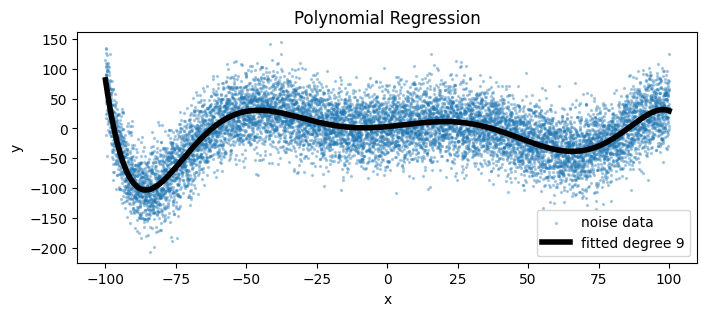

In [55]:
x_line = np.linspace(x.min(), x.max(), 500)
phi_line = des_mat(x_line, best_deg)
y_line = phi_line @ w_best

plt.figure(figsize=(8, 3))
plt.scatter(x, y, s=2, alpha=0.3, label="noise data")
plt.plot(x_line, y_line, color="black", linewidth=4, label=f"fitted degree {best_deg}")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Polynomial Regression")
plt.legend()
plt.savefig("Fitted_curve.png", dpi=150, bbox_inches='tight')
plt.show()

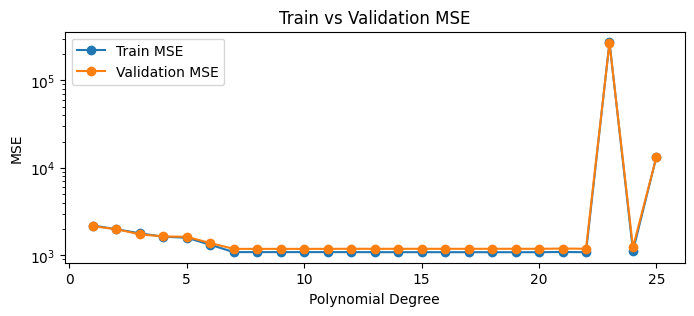

In [56]:
plt.figure(figsize=(8, 3))
plt.plot(degrees, train_err, marker='o', label="Train MSE")
plt.plot(degrees, val_err, marker='o', label="Validation MSE")
plt.yscale('log')
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Train vs Validation MSE")
plt.legend()
plt.savefig("MSE_vs_degree.png", dpi=150, bbox_inches='tight')
plt.show()